# The trapezoidal rule

This notebook shows how the composite trapezoidal rule works:

1. Implementing it in one line with NumPy
2. Seeing the trapezoids
3. Checking how fast it converges (second order)
4. Overestimates and underestimates
5. A chemistry example: the work of an isothermal expansion

$$
\int_a^b f(x)\,dx \approx \frac{h}{2}\sum_{i=0}^{N-2}\Big(f(x_i) + f(x_{i+1})\Big),
\qquad h = \frac{b-a}{N-1}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

## 1. Implementation

With NumPy we don't need a loop. `f[:-1]` holds the left end of every interval and `f[1:]` the right end, so `f[:-1] + f[1:]` gives the two parallel sides of every trapezoid at once.

In [2]:
def trapezoidal_rule(f, h):
    # composite trapezoidal rule for integrand values f on a uniform grid with spacing h
    return h / 2 * np.sum(f[:-1] + f[1:])

# test: the integral of sin(x) from 0 to pi is exactly 2
x = np.linspace(0, np.pi, 11)
h = x[1] - x[0]
I = trapezoidal_rule(np.sin(x), h)

print(f"Trapezoidal rule (N = 11): {I:.6f}")
print(f"NumPy np.trapezoid       : {np.trapezoid(np.sin(x), x):.6f}")
print(f"Exact                    : 2.000000")
print(f"Relative error           : {abs(I - 2) / 2:.2%}")

Trapezoidal rule (N = 11): 1.983524
NumPy np.trapezoid       : 1.983524
Exact                    : 2.000000
Relative error           : 0.82%


## 2. Seeing the trapezoids

Each orange shape is one trapezoid. The gap between the orange tops and the blue curve is the error.

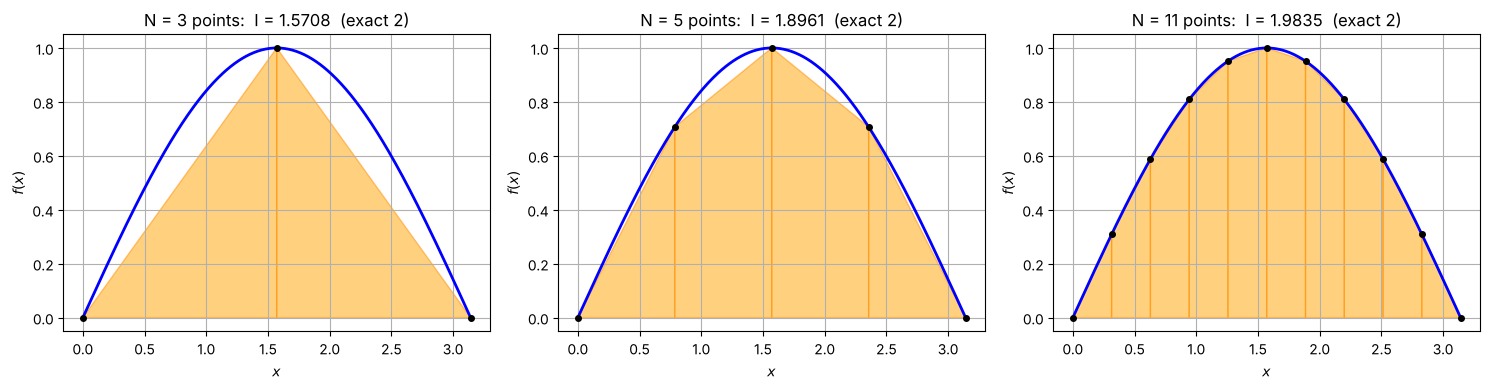

In [3]:
def plot_trapezoids(f, a, b, N, ax):
    x_fine = np.linspace(a, b, 400)
    x = np.linspace(a, b, N)
    y = f(x)
    for i in range(N - 1):
        ax.fill([x[i], x[i], x[i + 1], x[i + 1]], [0, y[i], y[i + 1], 0],
                facecolor="orange", edgecolor="darkorange", alpha=0.5)
    ax.plot(x_fine, f(x_fine), "b", lw=2, label=r"$f(x) = \sin x$")
    ax.plot(x, y, "ko", ms=4)
    I = trapezoidal_rule(y, x[1] - x[0])
    ax.set_title(f"N = {N} points:  I = {I:.4f}  (exact 2)")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$f(x)$")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, N in zip(axes, [3, 5, 11]):
    plot_trapezoids(np.sin, 0, np.pi, N, ax)
plt.tight_layout()
plt.show()

## 3. Convergence: the error goes as $h^2$

The theory says the error is $E = -\frac{(b-a)h^2}{12}f''(\xi)$.
So if we **halve** $h$ (roughly double $N$), the error should drop by a factor of about **4**.

In [4]:
print(f"{'N':>6} {'h':>10} {'integral':>12} {'error':>12} {'error ratio':>12}")
Ns = [3, 5, 9, 17, 33, 65, 129, 257]     # each step halves h
hs, errors = [], []
for N in Ns:
    x = np.linspace(0, np.pi, N)
    h = x[1] - x[0]
    I = trapezoidal_rule(np.sin(x), h)
    err = abs(I - 2)
    ratio = errors[-1] / err if errors else np.nan
    hs.append(h)
    errors.append(err)
    print(f"{N:>6} {h:>10.5f} {I:>12.8f} {err:>12.3e} {ratio:>12.3f}")

     N          h     integral        error  error ratio
     3    1.57080   1.57079633    4.292e-01          nan
     5    0.78540   1.89611890    1.039e-01        4.132
     9    0.39270   1.97423160    2.577e-02        4.031
    17    0.19635   1.99357034    6.430e-03        4.008
    33    0.09817   1.99839336    1.607e-03        4.002
    65    0.04909   1.99959839    4.016e-04        4.000
   129    0.02454   1.99989960    1.004e-04        4.000
   257    0.01227   1.99997490    2.510e-05        4.000


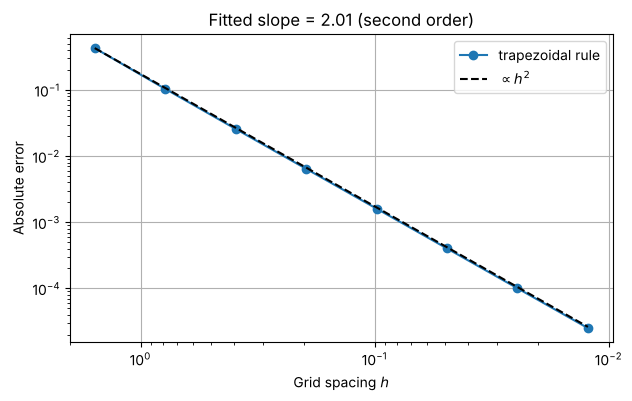

In [5]:
hs, errors = np.array(hs), np.array(errors)
slope = np.polyfit(np.log(hs), np.log(errors), 1)[0]

plt.loglog(hs, errors, "o-", label="trapezoidal rule")
plt.loglog(hs, errors[0] * (hs / hs[0])**2, "k--", label=r"$\propto h^2$")
plt.gca().invert_xaxis()
plt.xlabel("Grid spacing $h$")
plt.ylabel("Absolute error")
plt.title(f"Fitted slope = {slope:.2f} (second order)")
plt.legend()
plt.show()

The error ratio converges to 4, and the log–log slope is 2, which confirms that the method is **second order**.

## 4. Overestimate or underestimate?

The sign of $f''$ decides which:
* $f(x) = e^x$ curves upwards ($f''>0$), so the straight tops of the trapezoids lie **above** the curve and the rule **overestimates**.
* $f(x) = \sin x$ on $[0,\pi]$ curves downwards ($f''<0$), so the rule **underestimates** (as we saw above).
* For a straight line ($f''=0$) the rule is **exact**.

In [6]:
x = np.linspace(0, 1, 6)
h = x[1] - x[0]
tests = {
    "exp(x)  on [0,1]  (f'' > 0)": (np.exp(x), np.e - 1),
    "-x^2+1  on [0,1]  (f'' < 0)": (-x**2 + 1, 2 / 3),
    "3x + 2  on [0,1]  (f'' = 0)": (3 * x + 2, 3.5),
}
for name, (f, exact) in tests.items():
    I = trapezoidal_rule(f, h)
    verdict = "overestimate" if I > exact + 1e-12 else ("underestimate" if I < exact - 1e-12 else "exact")
    print(f"{name}: trapezoid = {I:.6f}, exact = {exact:.6f} -> {verdict}")

exp(x)  on [0,1]  (f'' > 0): trapezoid = 1.724006, exact = 1.718282 -> overestimate
-x^2+1  on [0,1]  (f'' < 0): trapezoid = 0.660000, exact = 0.666667 -> underestimate
3x + 2  on [0,1]  (f'' = 0): trapezoid = 3.500000, exact = 3.500000 -> exact


## 5. Chemistry example: reversible isothermal expansion

The work done on one mole of an ideal gas expanding reversibly from $V_1$ to $V_2$ at constant $T$ is

$$
w = -\int_{V_1}^{V_2} P\,dV = -\int_{V_1}^{V_2}\frac{RT}{V}\,dV = -RT\ln\frac{V_2}{V_1}.
$$

We compare the trapezoidal rule with this exact result for $T = 298.15$ K and an expansion from 1 L to 10 L.

In [7]:
R = 8.314462          # J K^-1 mol^-1
T = 298.15            # K
V1, V2 = 1e-3, 10e-3  # m^3 (1 L -> 10 L)

w_exact = -R * T * np.log(V2 / V1)
print(f"Exact work: w = {w_exact:.3f} J/mol\n")
print(f"{'N':>6} {'w (J/mol)':>14} {'error (J/mol)':>15}")
for N in [5, 10, 50, 100, 1000]:
    V = np.linspace(V1, V2, N)
    P = R * T / V                                 # Pa
    w = -trapezoidal_rule(P, V[1] - V[0])
    print(f"{N:>6} {w:>14.3f} {w - w_exact:>15.3f}")

Exact work: w = -5708.009 J/mol

     N      w (J/mol)   error (J/mol)
     5      -6517.726        -809.717
    10      -5897.360        -189.351
    50      -5714.885          -6.876
   100      -5709.698          -1.689
  1000      -5708.026          -0.017


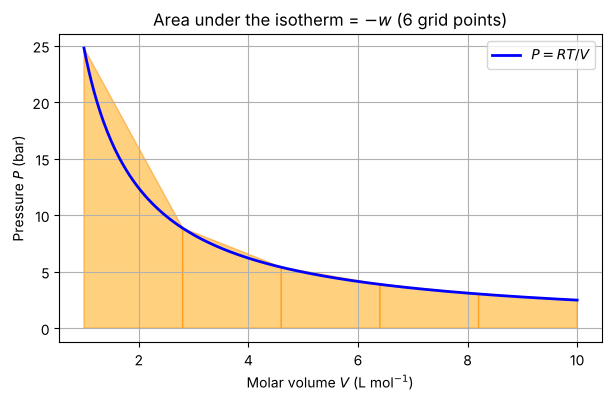

In [8]:
V_fine = np.linspace(V1, V2, 400)
V = np.linspace(V1, V2, 6)
P = R * T / V
for i in range(len(V) - 1):
    plt.fill([V[i] * 1e3, V[i] * 1e3, V[i + 1] * 1e3, V[i + 1] * 1e3],
             [0, P[i] / 1e5, P[i + 1] / 1e5, 0],
             facecolor="orange", edgecolor="darkorange", alpha=0.5)
plt.plot(V_fine * 1e3, R * T / V_fine / 1e5, "b", lw=2, label=r"$P = RT/V$")
plt.xlabel(r"Molar volume $V$ (L mol$^{-1}$)")
plt.ylabel(r"Pressure $P$ (bar)")
plt.title("Area under the isotherm = $-w$ (6 grid points)")
plt.legend()
plt.show()

$P = RT/V$ curves upwards ($f''>0$), so the trapezoidal rule **overestimates** the area. The computed work is therefore more negative than the exact value, and the error shrinks as we add grid points.
The error is largest at small $V$, where the isotherm is steepest. This is why the assignment uses very fine (or logarithmic) grids near the liquid branch of the van der Waals isotherm.